# Weekly Homework 2: Wine Quality

### Author: Elias Nicolas

## Introduction to Machine Learning

#### University of Redlands - DATA 301
#### Prof: Joanna Bieri [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
#### [Class Website](https://joannabieri.com/machine_learning.html)

---

**Due Sunday 9/13 at 11:59pm.** This covers Day 3 and Day 4.

GOALS:

1. Load and inspect a real file that is not as clean as it looks.
2. Use regularization on data where the features are genuinely related to each other.
3. Do cross validation properly, with pipelines, so nothing leaks.
4. Find a real leak in real data and measure what it costs you.
5. Say what your numbers actually mean.

**How to turn this in.** Your repository on GitHub **is** your submission. There is no Pull Request to open any more.

Manage your git however you like. Use branches if you want them, or commit straight to `main` if you do not. What I need is only this:

1. The finished work is on your **`main`** branch.
2. It is **pushed to GitHub** before the deadline.
3. Your name is on the **Author** line at the top of this notebook.

```bash
git add .
git commit -m "Weekly homework 2"
git push
```

If you did the work on a branch, merge it into `main` and push before the deadline:

```bash
git checkout main
git merge my-branch-name
git push
```

I grade from whatever is on GitHub at the deadline. If it is not pushed, I cannot see it.

**What I am grading.** Working code with no writing is not a pass. Every question that asks "why" or "what does this mean" needs real sentences. That is the part I actually care about.

This is a full mini project, so unlike the daily notes there are no optional parts here. Answer everything, in order. Several questions ask you to commit to a guess before you run the code, and those are there on purpose, so do not skip ahead and backfill them.

## The data

`data/winequality-red.csv`, 1599 Portuguese red wines. Eleven chemical measurements
per wine, plus a `quality` score from 0 to 10 given by wine tasters.

**The question:** can we predict a wine's quality score from its chemistry?

This is real data from a real study, which means it has real problems in it. Finding
them is Part 1.

---

# Part 1: Load it and look at it

**1a.** Load the file. It will not work the first time. Look at what you get, figure
out why, and fix it. Say in one sentence what was wrong. (Hint: open the raw file in a
text editor and look at what separates the columns.)

**1b.** How many rows and how many columns? What are the column names?

**1c.** Are there any missing values?

**1d.** Now check for **duplicate rows**, with `.duplicated().sum()`. How many are
there? That is a lot. Write two or three sentences on what you think they are: did
somebody measure the same wine twice, or are there genuinely two different wines with
identical readings on all eleven measurements? Which explanation do you believe, and
why?

**1e.** Look at `.describe()`. Compare the typical size of `density` to the typical
size of `total sulfur dioxide`. Roughly what factor separates them? Given Day 3, what
does that tell you that you must do before regularizing?

**1f.** Plot a histogram of `quality`. Is it balanced? Which scores are rare?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file = 'data/winequality-red.csv'
df = pd.read_csv(file,sep = ';')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
df.shape

(1599, 12)

In [3]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [4]:
df[df.isna().any(axis=1)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality


In [5]:
df.isna().values.any()

np.False_

In [6]:
df.duplicated().sum()

np.int64(240)

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


(array([ 10.,   0.,  53.,   0., 681.,   0., 638.,   0., 199.,  18.]),
 array([3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ]),
 <BarContainer object of 10 artists>)

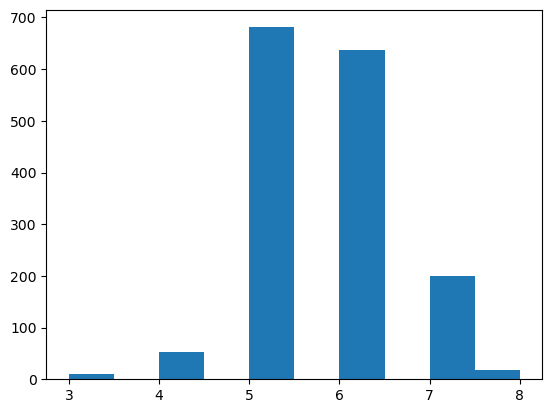

In [8]:
plt.hist(df['quality'])

*The dataframe was split by ';' (semicolons) instead of ',' (commas) as a csv is expected to be seperated by, hence why the initial upload did not work.*

*There are 1599 rows and 12 columns, the columns include: 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', and 'quality'.*

*There are no missing or NaN values in the dataset.*

*There are 240 duplicated rows in the dataset. I believe that these readings are not due to human error (i.e. repeating the same measurements twice) and rather that the wine samples simply shared similar values. A human mistake in data entry would result in maybe 5 to 10 duplicated samples however, it is highly unlikely that a person measured the same wine samples 240 times over and over again. This is also supported by the fact that we can infer that the wine samples in this dataset come from the same facility, meaning they use the same equipment, formula, and produce needed to make the wine thus resulting in similar results.*

*The density is smaller than the total sulfur dioxide by a factor of about a hundred, this means that we must use StandardScaler() to scale our features before training a model.*

*The quality scores are not balanced as it is rare for a wine sample to recieve a score of either 3, 4, 7, or 8.*

---

# Part 2: Split first

Before you explore any relationships, split off a test set. Day 4 was clear about why:
if you look at everything first, your later choices are shaped by what you saw.

**2a.** Decide what to do about the duplicates you found in 1d, and **do it before you
split**. Whatever you decide, defend it in two or three sentences. There is a defensible
argument either way, and I am grading the argument, not the choice.

**2b.** Split into a training set and a test set, 75/25. Use `stratify=` on the quality
score so both sets have a similar mix of quality levels.

**2c.** Why did stratifying matter here specifically? Point at something from your 1f
histogram.

**2d.** Print the shape of both sets, and check that the proportion of each quality
score really is similar in the two.

**Now put the test set away and do not touch it again until Part 6.**

In [98]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['quality'])
y = df[['quality']] 

X_train_main, X_test_main, y_train_main, y_test_main = train_test_split(
    X, y, random_state = 42, test_size=0.25, stratify=df['quality']) 

print(f"Original Shape: {X.shape}")
print(f"Training Set Shape: {X_train_main.shape}")
print(f"Testing Set Shape: {X_test_main.shape}")

Original Shape: (1599, 11)
Training Set Shape: (1199, 11)
Testing Set Shape: (400, 11)


In [42]:
y_train.describe()

,quality
count,1199.000000
mean,5.633028
std,0.808207
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


In [43]:
y_test.describe()

,quality
count,400.000000
mean,5.645000
std,0.806599
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


*I decided to keep the duplicates found previously in part 1, since based on my prior argument in part 1 I assume these rows are not just the same wine samples measured twice. It is more likely that these rows are wine samples that share similar or the same numerical values, as it is not plausible for wine samples to be remeasured multiple times for a total of 240 duplicated rows.*

*It is important to stratify our data because as seen in our plot in part 1 the data is not equally distributed, with some quality scores appearing way more than others. We want to ensure the training and test set have a similar distribution of data which is why we stratified.*

---

# Part 3: A baseline, then regularization

Never report a model score without something to compare it to.

**3a.** What RMSE would you get by ignoring the chemistry entirely and predicting the
**mean quality** for every wine? Compute it with 5-fold cross validation on the
training set. This is the number every model has to beat.

**3b.** Build a pipeline of `StandardScaler` and `LinearRegression`. Get its 5-fold
cross validation RMSE on the training set. Print all five fold scores, not just the
mean.

**3c.** How much better is it than the baseline? Is the improvement bigger or smaller
than the spread across your five folds? Say what that comparison means.

**3d.** Now `Ridge` and `Lasso`. Use `GridSearchCV` to choose alpha for each, over at
least 20 values with `np.logspace`. Report the best alpha and CV RMSE for each.

**3e.** Do Ridge and Lasso beat plain `LinearRegression` here? Day 3 said regularizing
almost always helps. Did it help much this time? Suggest a reason based on how many
features and how many rows you have.

In [90]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV

In [91]:
dummy = DummyRegressor(strategy='mean')

scores = cross_val_score(dummy, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
fold_rmse = -scores

for i, s in enumerate(fold_rmse, start=1):
    print(f"  fold {i}: RMSE = {s:.3f}")

print(f"\nmean RMSE = {fold_rmse.mean():.3f}")
print(f"spread    = {fold_rmse.std():.3f}  (from {fold_rmse.min():.3f} to {fold_rmse.max():.3f})")

  fold 1: RMSE = 0.885
  fold 2: RMSE = 0.715
  fold 3: RMSE = 0.840
  fold 4: RMSE = 0.767
  fold 5: RMSE = 0.827

mean RMSE = 0.807
spread    = 0.059  (from 0.715 to 0.885)


In [92]:
lin_reg = LinearRegression()

model = make_pipeline(
    StandardScaler(),
    lin_reg)

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
fold_rmse = -scores

for i, s in enumerate(fold_rmse, start=1):
    print(f"  fold {i}: RMSE = {s:.3f}")

print(f"\nmean RMSE = {fold_rmse.mean():.3f}")
print(f"spread    = {fold_rmse.std():.3f}  (from {fold_rmse.min():.3f} to {fold_rmse.max():.3f})")

  fold 1: RMSE = 0.693
  fold 2: RMSE = 0.646
  fold 3: RMSE = 0.655
  fold 4: RMSE = 0.646
  fold 5: RMSE = 0.686

mean RMSE = 0.665
spread    = 0.020  (from 0.646 to 0.693)


In [93]:
alphas = np.logspace(-5, 4, 20)

pipe = make_pipeline(
    StandardScaler(),
    Ridge())

param_grid = {"ridge__alpha": alphas}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="neg_root_mean_squared_error")
grid.fit(X_train, y_train)

print("best alpha  =", round(grid.best_params_["ridge__alpha"], 3))
print("its CV RMSE =", round(-grid.best_score_, 3))

best alpha  = 42.813
its CV RMSE = 0.664


In [94]:
pipe = make_pipeline(
    StandardScaler(),
    Lasso())

param_grid = {"lasso__alpha": alphas}

lasso_grid = GridSearchCV(pipe, param_grid, cv=5, scoring="neg_root_mean_squared_error")
lasso_grid.fit(X_train, y_train)

print("best alpha  =", round(lasso_grid.best_params_["lasso__alpha"], 3))
print("its CV RMSE =", round(-lasso_grid.best_score_, 3))

best alpha  = 0.021
its CV RMSE = 0.665


In [95]:
print(f"Difference between Linear Regression RMSE and Baseline: {0.807-0.665}")

Difference between Linear Regression RMSE and Baseline: 0.14200000000000002


*The Linear Regression RMSE score is smaller than the baseline by a value of about 0.14 meaning that linear regression is more reliable than our baseline.*

*In this scenario the Ridge and Lasso model did not beat our regular linear regression model. Regularization did not help in this scenario as there are only 11 features meaning that there is little overfitting to fix in the first place.*

---

# Part 4: Which chemistry actually matters

**4a.** Take your tuned Lasso and print its coefficients next to the feature names.
Which features did it zero out?

**4b.** Now sweep alpha by hand over about four values and print how many features
survive at each. Find an alpha that keeps only about **three** features. Which three?

**4c.** Compare those three to the correlation of each feature with `quality`, which
you can get with `.corr()`. Do they agree?

**4d.** A winemaker reads your result and says "so if I add more sulphates, my wine
will score higher." What is wrong with that conclusion? Two or three sentences.

**4e.** From Day 3: two of your eleven features are strongly related to each other.
Find a pair with correlation above 0.6. If Lasso kept one and dropped the other, what
should you **not** conclude about the dropped one?

In [56]:
best_lasso = lasso_grid.best_estimator_.named_steps['lasso']

coef_table = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': best_lasso.coef_
})

print(coef_table)

zeroed = coef_table[coef_table['coefficient'] == 0]
print("\nFeatures zeroed out:", list(zeroed['feature']))

                 feature  coefficient
0          fixed acidity    -0.000000
1       volatile acidity    -0.202553
2            citric acid    -0.038120
3         residual sugar     0.003508
4              chlorides    -0.074599
5    free sulfur dioxide     0.055261
6   total sulfur dioxide    -0.116969
7                density    -0.000000
8                     pH    -0.088876
9              sulphates     0.129178
10               alcohol     0.313865

Features zeroed out: ['fixed acidity', 'density']


In [59]:
alphas_to_try = [0.001, 0.01, 0.1, 1]

for alpha in alphas_to_try:
    pipe = make_pipeline(StandardScaler(), Lasso(alpha=alpha))
    pipe.fit(X_train, y_train)
    
    coefs = pipe.named_steps['lasso'].coef_
    n_survived = np.sum(coefs != 0)
    
    survivors = X_train.columns[coefs != 0]
    
    print(f"alpha = {alpha}: {n_survived} features survived : {list(survivors)}")

alpha = 0.001: 10 features survived : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']
alpha = 0.01: 8 features survived : ['volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']
alpha = 0.1: 3 features survived : ['volatile acidity', 'sulphates', 'alcohol']
alpha = 1: 0 features survived : []


In [62]:
mask = ['volatile acidity', 'sulphates', 'alcohol', 'quality']
df_corr = df[mask]
df_corr.corr()

,volatile acidity,sulphates,alcohol,quality
volatile acidity,1.000000,-0.260987,-0.202288,-0.390558
sulphates,-0.260987,1.000000,0.093595,0.251397
alcohol,-0.202288,0.093595,1.000000,0.476166
quality,-0.390558,0.251397,0.476166,1.000000


In [73]:
df.corr().abs() > 0.6

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,True,False,True,False,False,False,False,True,True,False,False,False
volatile acidity,False,True,False,False,False,False,False,False,False,False,False,False
citric acid,True,False,True,False,False,False,False,False,False,False,False,False
residual sugar,False,False,False,True,False,False,False,False,False,False,False,False
chlorides,False,False,False,False,True,False,False,False,False,False,False,False
free sulfur dioxide,False,False,False,False,False,True,True,False,False,False,False,False
total sulfur dioxide,False,False,False,False,False,True,True,False,False,False,False,False
density,True,False,False,False,False,False,False,True,False,False,False,False
pH,True,False,False,False,False,False,False,False,True,False,False,False
sulphates,False,False,False,False,False,False,False,False,False,True,False,False


*The features that were zero'd out include 'fixed acidity' and 'density'.*

*An alpha of 0.1 keeps the columns: 'volatile acidity', 'sulphates', and 'alcohol'.*

*No, the three features do not agree with the correlation with quality, as some features have a higher correlation to quality than others.*

*Adding more sulphates wouldn't necessary improve the quality of the wine as it does not take into account the other features that play into making a quality wine. Just because you increase the amount of sulphates used, does not mean the quality score will directly go up as there are other important features needed not accounted for in the model.*

*You should not conclude that the dropped feature is not as important as a kept feature.*

---

# Part 5: The leak that is already in your data

Back to those duplicate rows. This part shows you what they cost.

**5a.** Before you run anything, guess. If you leave the duplicates in and split
randomly, some identical wines will land in **both** the training and the test set.
Out of 400 test rows, how many do you think will be exact copies of a training row?
Write a number down.

**5b.** Now measure it. Using the **original** data with duplicates still in, split it
randomly and count how many test rows appear identically in the training set.

**5c.** Fit the same model two ways and compare the test RMSE:

- on the data **with** duplicates left in
- on the **deduplicated** data

Average over at least 5 different `random_state` values for the split, because Day 4
taught you that one split proves nothing.

**5d.** Which one scores better? By how much? Which number is the honest one?

**5e.** Explain in your own words why duplicate rows across a split are a form of
leakage. Connect it to the patient scans example from the Day 4 notes.

**5f.** Suppose these duplicates are genuinely different wines that happen to have
identical chemistry, rather than the same wine recorded twice. Does that change your
answer to 5e? Think carefully, this one is not obvious.

In [74]:
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [78]:
X = df.drop(columns=['quality'])
y = df[['quality']] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = 42, test_size=0.25, stratify=df['quality']) 

print(f"Total duplicates in training set: {X_train.duplicated().sum()}")

Total duplicates in training set: 139


In [99]:
df_no_dups = df.copy()
df_no_dups = df.drop_duplicates()

random_states = [40, 41, 42, 43, 44, 45]

rmse_no_dup = []
rmse_dup = []

for i in random_states: 
    X = df.drop(columns=['quality'])
    y = df[['quality']] 

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state = i, test_size=0.25, stratify=df['quality'])

    model = make_pipeline(StandardScaler(), LinearRegression()) 
    model.fit(X_train, y_train)
    preds = model.predict(X_test) 
    rmse_dup.append(root_mean_squared_error(y_test, preds))
    
    X_no_dups = df_no_dups.drop(columns=['quality'])
    y_no_dups = df_no_dups[['quality']]
    
    X_no_dups_train, X_no_dups_test, y_no_dups_train, y_no_dups_test = train_test_split(
        X_no_dups, y_no_dups, random_state = i, test_size=0.25, stratify=df_no_dups['quality'])

    model = make_pipeline(StandardScaler(), LinearRegression()) 
    model.fit(X_no_dups_train, y_no_dups_train)
    preds = model.predict(X_no_dups_test) 
    rmse_no_dup.append(root_mean_squared_error(y_no_dups_test, preds))

print(f"RMSE with duplicates {np.mean(rmse_dup)}")
print(f"RMSE with no duplicates {np.mean(rmse_no_dup)}")
print(f"Difference between the RMSE scores: {np.mean(rmse_no_dup)-np.mean(rmse_dup)}")

RMSE with duplicates 0.6428340441211922
RMSE with no duplicates 0.6672748293927117
Difference between the RMSE scores: 0.024440785271519494


*The RMSE score based off the dataset with duplicates has the better score by about 0.02, however this is not the honest RMSE score. The dataset with no duplicates is the honest RMSE score since it doesn't have any leaks, as there is no way the testing set and training set share duplicate rows when split.*

*Duplicate rows are a form of leakage because the model knows something it should not, as duplicates can be found in both the training and testing set. This leads the model to be more accurate solely because it has shared data between the two sets, not because the model is more accurate.*

*No it would not change my answer to 5e, because even though the data is from two different wine samples the model will not be able to interpret that. So for the sake of developing the model further I would cut out the duplicated rows to prevent any leaks.*

---

# Part 6: The test set, once

**6a.** Take your single best model from Part 3, refit it on the whole training set,
and score it on the test set you have not touched since Part 2. Report the RMSE.

**6b.** Compare it to the cross validation RMSE you got for that model in Part 3. Is it
better or worse? Is the difference bigger than the spread across your folds?

**6c.** Quality scores run from 3 to 8 in this data. Write one sentence a winemaker
would understand about how accurate your model is, using your test RMSE and that scale.

**6d.** Would you use this model to decide the price of a bottle? Answer yes or no and
defend it. Consider both how accurate it is and what happens when it is wrong.

**6e.** One last one, and it previews Day 5. Instead of predicting the score, suppose
we only wanted to flag **good** wines, meaning quality 7 or above. Work out what
fraction of the wines that is. Then say what accuracy you would get from a model that
ignores the chemistry completely and always answers "not good". What does that tell
you about using accuracy to judge a model like this?

In [103]:
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha = 42.813),
)

model.fit(X_train_main, y_train_main) 
results = model.predict(X_test_main) 

RMSE = root_mean_squared_error(y_test_main, results)
print(f"Final RMSE: {RMSE}")

Final RMSE: 0.6414727458205914


In [114]:
mask = df['quality'] > 6
percent = round(df[mask].shape[0]/(df.shape[0]) * 100, 4)
print(f"Percentage of wines with quality score of 7 or above: {percent}%")

Percentage of wines with quality score of 7 or above: 13.571%


*The Final RMSE score is better than the score found in Part 3, with the difference being less than the spread across the folds.*

*I would tell a winemaker the model is able to predict a quality score with there being about a one score uncertainty since the scores are only seperated by increments of 1 from 3 to 8.*

*I would not use this model to price a bottle of wine simply because the scale on which the quality scores are on is not accurate enough as it only has tick values of 1. This means once my model makes a prediction, I may be put in a scenario where I'd either have to round up the score or round down the score, depending on the predicted score. This may lead to be making a higher quality botter cheaper or a lower quality bottle too expensive, which affects the revenue.*

*About 13.6% of wines have a quality score of 7 or above, a model that always answers not good would miss this percentage of wines that were in fact good. This tells me that accuracy used to judge a model such as this one is essential, as a misinterpretation of data can affect my model drastically.*

---